In [80]:
import pandas as pd
import numpy as np
from src.preprocessing import load_data, merge_data, change_dtypes
from sklearn.feature_selection import mutual_info_classif

In [81]:
df1, df2 = load_data(['data/interview homework file A.csv', 'data/interview homework file B.csv']) # Load the two datasets from the specified file paths
df = merge_data(df1, df2, on='ID') # Merge the two datasets on the 'ID' column after removing subcode '--xxx'
df = change_dtypes(df, str_cols=['ID'], date_cols=['APPLICATION_DATE']) # Change the data types of specified columns
#df['AGE'] = df['APPLICATION_DATE'].dt.year - df['birth_year'].dt.year # Calculate the age of each individual by subtracting the birth year from the application year
df['AGE_AT_APPLICATION'] = df['APPLICATION_DATE'].dt.year - df['birth_year']

In [75]:
df_2023 = df[df['APPLICATION_DATE'].dt.year == 2023] # Filter the dataset to include only rows where the application date is in the year 2023

In [79]:
(df['AGE']-df['AGE_AT_APPLICATION']).min()

np.float64(1.0833320999999998)

In [88]:
df.columns

Index(['ID', 'DEFAULT', 'CARDHLDR', 'SPENDING', 'APPLICATION_DATE', 'AGE',
       'ACADMOS', 'ADEPCNT', 'MAJORDRG', 'MINORDRG', 'OWNRENT',
       'MONTHLY_INCOME', 'SELFEMPL', 'MAJORDRG_lag1', 'MAJORDRG_lag2',
       'MAJORDRG_lag3', 'MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6',
       'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10',
       'MAJORDRG_lag11', 'MAJORDRG_lag12', 'MINORDRG_lag1', 'MINORDRG_lag2',
       'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6',
       'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10',
       'MINORDRG_lag11', 'MINORDRG_lag12', 'birth_year', 'ANNUAL_INCOME',
       'AGE_AT_APPLICATION'],
      dtype='str')

In [90]:
df['ADEPCNT'].describe()

count    13444.000000
mean         1.017257
std          1.279098
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: ADEPCNT, dtype: float64

In [93]:
(df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: row.sum(), axis=1) == df['MAJORDRG']).sum()

np.int64(13444)

np.int64(13444)

In [86]:
df['MONTHLY_INCOME'].describe()

count    13444.000000
mean      2509.527819
std       1252.946716
min         50.000000
25%       1666.666667
50%       2166.666667
75%       2916.666667
max       8333.250000
Name: MONTHLY_INCOME, dtype: float64

In [49]:
max_app_date = df['APPLICATION_DATE'].max()
min_app_date = df['APPLICATION_DATE'].min()
print(f"Application date range: {min_app_date} to {max_app_date}")

df['months_observed'] = (max_app_date - df['APPLICATION_DATE']).dt.days // 30
(df["months_observed"] < 12).mean()

Application date range: 2021-01-01 00:00:00 to 2023-12-01 00:00:00


np.float64(0.33368045224635523)

In [48]:
df["bucket"] = pd.cut(df["months_observed"], bins=[0,6,12,24,36])

df.groupby("bucket")["DEFAULT"].mean()

bucket
(0, 6]      0.079858
(6, 12]     0.082814
(12, 24]    0.074125
(24, 36]    0.066699
Name: DEFAULT, dtype: float64

In [54]:
df['AGE'] = df['APPLICATION_DATE'].dt.year - df['birth_year']
#df['MAJORDRG_lag_concentration'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
#df['MINORDRG_lag_concentration'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

df['INCOME_PER_DEP'] = df['MONTHLY_INCOME'] / (df['ADEPCNT'] + 1)
df['INCOME_LOG'] = np.log1p(df['MONTHLY_INCOME'])
df['ACADMOS_LOG'] = np.log1p(df['ACADMOS'])

df.drop(columns=['MONTHLY_INCOME', 'ACADMOS'], inplace=True)

df['MAJORDRG_max'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)
df['MINORDRG_max'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)

"""bins = [-0.1, 25, 50, np.inf]
df['AGE_APP'] = pd.cut(df['AGE_APP'], bins=bins, labels=[0, 1, 2], right=False).astype(int)

df['APPLICATION_MONTH_SIN'] = np.sin(2 * np.pi * df['APPLICATION_DATE'].dt.month / 12)
df['APPLICATION_MONTH_COS'] = np.cos(2 * np.pi * df['APPLICATION_DATE'].dt.month / 12)

df['MAJORDRG_lag_concentration'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['MINORDRG_lag_concentration'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)
df['INCOME_PER_DEP'] = df['MONTHLY_INCOME'] / (df['ADEPCNT'] + 1)
df['INCOME_LOG'] = np.log1p(df['MONTHLY_INCOME'])
df.drop(columns=['MONTHLY_INCOME'], inplace=True)

df['MAJORDRG_max'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)"""

cols_to_drop = ['birth_year', 'SPENDING', 'ANNUAL_INCOME', 'AGE']
df = df.drop(columns=cols_to_drop)

X = df.drop(columns=['CARDHLDR', 'ID', 'DEFAULT'])
y = df['DEFAULT']
approved_mask = df['CARDHLDR']

# time based split
cutoff_date = df[df['CARDHLDR']==1]['APPLICATION_DATE'].quantile(0.85)

train_mask = (df['APPLICATION_DATE'] <= cutoff_date) & (approved_mask == 1)
test_mask = (df['APPLICATION_DATE'] > cutoff_date) & (approved_mask == 1)

X_train, y_train = X[train_mask].drop(columns=['APPLICATION_DATE']), y[train_mask]
X_test, y_test = X[test_mask].drop(columns=['APPLICATION_DATE']), y[test_mask]

# drop columns with zero variance
zero_var_cols = X_train.columns[X_train.nunique() <= 1]
X_train = X_train.drop(columns=zero_var_cols)
X_test = X_test.drop(columns=zero_var_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [10]:
df.describe()

,DEFAULT,CARDHLDR,APPLICATION_DATE,AGE,ACADMOS,ADEPCNT,MAJORDRG,MINORDRG,OWNRENT,MONTHLY_INCOME,...,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,birth_year,ANNUAL_INCOME
count,13444.000000,13444.000000,13444,13444.000000,13444.000000,13444.000000,13444.000000,13444.000000,13444.000000,13444.000000,...,13444.000000,13444.000000,13444.0,13444.0,13444.0,13444.0,13444.0,13444.000000,13444,13444.000000
mean,0.074085,0.780943,2022-06-14 16:09:53.394823,33.471828,55.318878,1.017257,0.462809,0.290539,0.455965,2509.527819,...,0.000149,0.000074,0.0,0.0,0.0,0.0,0.0,0.238248,1970-01-01 00:00:00.000001991,30114.333829
min,0.000000,0.000000,2021-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1970-01-01 00:00:00.000001936,600.000000
25%,0.000000,1.000000,2021-09-01 00:00:00,25.666666,12.000000,0.000000,0.000000,0.000000,0.000000,1666.666667,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1970-01-01 00:00:00.000001985,20000.000000
50%,0.000000,1.000000,2022-06-01 00:00:00,31.500000,30.000000,1.000000,0.000000,0.000000,0.000000,2166.666667,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1970-01-01 00:00:00.000001993,26000.000000
75%,0.000000,1.000000,2023-04-01 00:00:00,39.333332,72.000000,2.000000,0.000000,0.000000,1.000000,2916.666667,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1970-01-01 00:00:00.000001999,35000.000000
max,1.000000,1.000000,2023-12-01 00:00:00,88.666664,576.000000,9.000000,22.000000,11.000000,1.000000,8333.250000,...,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,6.000000,1970-01-01 00:00:00.000002025,99999.000000
std,0.261919,0.413623,NaN,10.226484,63.089729,1.279098,1.432724,0.767620,0.498076,1252.946716,...,0.012196,0.008625,0.0,0.0,0.0,0.0,0.0,0.594045,NaN,15035.360591


In [33]:
mi = mutual_info_classif(
    df[df['CARDHLDR']==1][['MONTHS_SINCE_LAST_MAJORDRG', 'INCOME_PER_DEP', 'INCOME_LOG', 'ACADMOS_LOG', 'MAJORDRG_max', 'MINORDRG_max']],
    df[df['CARDHLDR']==1]['DEFAULT']
)
pd.Series(mi, index=['MONTHS_SINCE_LAST_MAJORDRG', 'INCOME_PER_DEP', 'INCOME_LOG', 'ACADMOS_LOG', 'MAJORDRG_max', 'MINORDRG_max']).sort_values(ascending=False)

INCOME_LOG                    0.003817
MONTHS_SINCE_LAST_MAJORDRG    0.001960
MINORDRG_max                  0.001862
INCOME_PER_DEP                0.001620
MAJORDRG_max                  0.001095
ACADMOS_LOG                   0.000204
dtype: float64

In [59]:
mi = mutual_info_classif(df[df['CARDHLDR']==1].drop(columns=['CARDHLDR', 'ID', 'APPLICATION_DATE', 'DEFAULT']), df[df['CARDHLDR']==1]['DEFAULT'])
pd.Series(mi, index=df.drop(columns=['CARDHLDR', 'ID', 'APPLICATION_DATE', 'DEFAULT']).columns).sort_values(ascending=False)

MAJORDRG_lag6     0.006926
MINORDRG_lag6     0.005664
MAJORDRG          0.005023
MAJORDRG_lag7     0.004941
MINORDRG_lag8     0.004105
MAJORDRG_lag10    0.002922
MAJORDRG_lag4     0.002730
INCOME_PER_DEP    0.002277
MINORDRG_lag9     0.002221
OWNRENT           0.002154
MINORDRG_lag1     0.001922
MINORDRG_lag7     0.001854
MINORDRG_lag2     0.001783
SELFEMPL          0.001680
INCOME_LOG        0.001299
MINORDRG_max      0.000940
MAJORDRG_max      0.000747
MAJORDRG_lag11    0.000660
MINORDRG_lag3     0.000634
MAJORDRG_lag3     0.000466
MAJORDRG_lag12    0.000067
MINORDRG_lag11    0.000000
ACADMOS_LOG       0.000000
MINORDRG          0.000000
MAJORDRG_lag1     0.000000
MINORDRG_lag12    0.000000
MAJORDRG_lag2     0.000000
MINORDRG_lag10    0.000000
MAJORDRG_lag5     0.000000
MAJORDRG_lag8     0.000000
MINORDRG_lag5     0.000000
MINORDRG_lag4     0.000000
MAJORDRG_lag9     0.000000
ADEPCNT           0.000000
dtype: float64

In [60]:
df_approved = df[df['CARDHLDR']==1]
df_last_year_removed = df_approved[df_approved['APPLICATION_DATE'] < '2023-01-01']

mi = mutual_info_classif(df_last_year_removed.drop(columns=['CARDHLDR', 'ID', 'APPLICATION_DATE', 'DEFAULT']), df_last_year_removed['DEFAULT'])
pd.Series(mi, index=df_last_year_removed.drop(columns=['CARDHLDR', 'ID', 'APPLICATION_DATE', 'DEFAULT']).columns).sort_values(ascending=False)

MAJORDRG_lag3     0.004530
MINORDRG_lag9     0.003998
MAJORDRG_lag6     0.003584
SELFEMPL          0.002912
MINORDRG_lag3     0.002116
MINORDRG_lag10    0.002007
MINORDRG_max      0.001794
OWNRENT           0.001660
MAJORDRG          0.001577
MAJORDRG_lag10    0.001411
MAJORDRG_lag12    0.000984
ACADMOS_LOG       0.000432
INCOME_LOG        0.000253
INCOME_PER_DEP    0.000000
MINORDRG_lag12    0.000000
MINORDRG_lag5     0.000000
MINORDRG_lag11    0.000000
MINORDRG_lag8     0.000000
MINORDRG_lag7     0.000000
MAJORDRG_max      0.000000
MINORDRG_lag6     0.000000
ADEPCNT           0.000000
MINORDRG_lag4     0.000000
MINORDRG_lag2     0.000000
MAJORDRG_lag11    0.000000
MAJORDRG_lag9     0.000000
MAJORDRG_lag8     0.000000
MAJORDRG_lag7     0.000000
MAJORDRG_lag5     0.000000
MAJORDRG_lag4     0.000000
MAJORDRG_lag2     0.000000
MAJORDRG_lag1     0.000000
MINORDRG          0.000000
MINORDRG_lag1     0.000000
dtype: float64

In [63]:
df_approved['APPLICATION_YEAR'] = df_approved['APPLICATION_DATE'].dt.year
df_approved.groupby('APPLICATION_YEAR')['DEFAULT'].mean()

APPLICATION_YEAR
2021    0.092068
2022    0.092544
2023    0.099943
Name: DEFAULT, dtype: float64

In [31]:
df['MONTHS_SINCE_LAST_MAJORDRG'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: next((i for i in range(1, 13) if row[f'MAJORDRG_lag{i}'] > 0), 13), axis=1)

In [37]:
df['MONTHS_SINCE_LAST_MAJORDRG'].unique()

array([13,  1, 12])

In [42]:
df[df['CARDHLDR']==1][[f'MAJORDRG_lag{i}' for i in range(1, 13)]+['DEFAULT']].to_csv('majordrg_lags.csv', index=False)

In [36]:
df[df['CARDHLDR']==1].groupby('DEFAULT')['MONTHS_SINCE_LAST_MAJORDRG'].value_counts(normalize=True)

DEFAULT  MONTHS_SINCE_LAST_MAJORDRG
0        13                            0.839103
         12                            0.125855
         1                             0.035042
1        13                            0.833333
         12                            0.130522
         1                             0.036145
Name: proportion, dtype: float64

In [66]:
df_last_year_removed.drop(columns=['CARDHLDR', 'ID', 'APPLICATION_DATE']).groupby('DEFAULT').mean()

,ADEPCNT,MAJORDRG,MINORDRG,OWNRENT,SELFEMPL,MAJORDRG_lag1,MAJORDRG_lag2,MAJORDRG_lag3,MAJORDRG_lag4,MAJORDRG_lag5,...,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,INCOME_PER_DEP,INCOME_LOG,ACADMOS_LOG,MAJORDRG_max,MINORDRG_max
DEFAULT,,,,,,,,,,,,,,,,,,,,,
0,0.997789,0.330807,0.260698,0.462498,0.054634,0.058582,0.019896,0.008843,0.003790,0.001895,...,0.0,0.0,0.0,0.0,0.216959,1652.223150,7.742555,3.470441,0.255013,0.225328
1,0.961180,0.364907,0.288820,0.437888,0.063665,0.052795,0.012422,0.006211,0.003106,0.000000,...,0.0,0.0,0.0,0.0,0.267081,1546.961831,7.672389,3.490923,0.310559,0.268634


In [ ]:
ob = OptimalBinning(name='AGE', dtype='numerical', solver='cp')

ob.fit(df[df['CARDHLDR'] == 1]['AGE'].values, df[df['CARDHLDR'] == 1]['DEFAULT'].values)

print(ob.binning_table.build())

                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 22.29)    850   0.080960        729    121    0.142353   
1       [22.29, 24.62)   1177   0.112106       1061    116    0.098556   
2       [24.62, 28.79)   2103   0.200305       1900    203    0.096529   
3       [28.79, 31.29)   1024   0.097533        933     91    0.088867   
4       [31.29, 32.96)    672   0.064006        631     41    0.061012   
5       [32.96, 34.88)    680   0.064768        628     52    0.076471   
6       [34.88, 39.12)   1287   0.122583       1169    118    0.091686   
7       [39.12, 44.79)   1269   0.120869       1152    117    0.092199   
8         [44.79, inf)   1437   0.136870       1300    137    0.095338   
9              Special      0   0.000000          0      0    0.000000   
10             Missing      0   0.000000          0      0    0.000000   
Totals                  10499   1.000000       9503    996    0.094866   

             WoE        IV           

In [5]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(df[df['CARDHLDR']==1].drop(columns=['DEFAULT', 'birth_year', 'AGE', 'ANNUAL_INCOME', 'APPLICATION_DATE']), df[df['CARDHLDR']==1]['DEFAULT'], discrete_features='auto', random_state=42)
pd.Series(mi, index=df[df['CARDHLDR']==1].drop(columns=['DEFAULT', 'birth_year', 'AGE', 'ANNUAL_INCOME', 'APPLICATION_DATE']).columns).sort_values(ascending=False)

MINORDRG          0.004974
MINORDRG_lag9     0.004973
MONTHLY_INCOME    0.004939
MINORDRG_lag12    0.003454
MAJORDRG          0.003080
MAJORDRG_lag8     0.002173
MINORDRG_lag1     0.002105
MAJORDRG_lag3     0.001933
MINORDRG_lag10    0.001232
MINORDRG_lag8     0.001001
MAJORDRG_lag9     0.000768
MAJORDRG_lag4     0.000582
MAJORDRG_lag5     0.000516
SELFEMPL          0.000422
MINORDRG_lag4     0.000365
OWNRENT           0.000146
MINORDRG_lag3     0.000000
MINORDRG_lag11    0.000000
ACADMOS           0.000000
MINORDRG_lag7     0.000000
MINORDRG_lag6     0.000000
MINORDRG_lag5     0.000000
MAJORDRG_lag11    0.000000
MINORDRG_lag2     0.000000
MAJORDRG_lag12    0.000000
ADEPCNT           0.000000
MAJORDRG_lag10    0.000000
CARDHLDR          0.000000
MAJORDRG_lag7     0.000000
MAJORDRG_lag6     0.000000
MAJORDRG_lag2     0.000000
MAJORDRG_lag1     0.000000
ID                0.000000
dtype: float64

In [80]:
df

,ID,DEFAULT,CARDHLDR,SPENDING,APPLICATION_DATE,AGE,ACADMOS,ADEPCNT,MAJORDRG,MINORDRG,...,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,birth_year,ANNUAL_INCOME
0,528199,0,1,103.0623929,2022-09-01,22.166666,122,1,0,0,...,0,0,0,0,0,0,0,0,2002,17000.0
1,989446,0,1,95.4249982,2022-06-01,23.833334,6,4,0,1,...,0,0,0,0,0,0,0,1,2001,20800.0
2,687594,0,1,117.4366754,2023-05-01,46.583332,48,1,0,0,...,0,0,0,0,0,0,0,0,1978,50400.0
3,996978,0,1,55.6737483,2023-10-01,38.166668,14,2,0,0,...,0,0,0,0,0,0,0,0,1986,23240.0
4,881043,0,0,,2022-10-01,28.833334,36,0,5,1,...,0,0,0,0,0,0,0,1,1996,28000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13716,553480,0,1,361.9436175,2022-10-01,24.250000,13,0,0,0,...,0,0,0,0,0,0,0,0,2000,20640.0
13717,571968,0,1,157.4866660,2023-06-01,31.166666,29,2,0,0,...,0,0,0,0,0,0,0,0,1993,60000.0
13718,639249,0,0,,2023-04-01,40.166668,3,0,2,0,...,0,0,0,0,0,0,0,0,1984,25200.0
13719,793707,1,1,19.8762212,2022-01-01,35.250000,48,2,0,0,...,0,0,0,0,0,0,0,0,1989,24000.0


In [26]:
df[df['MAJORDRG']>20]

,ID,DEFAULT,CARDHLDR,ACADMOS,ADEPCNT,MAJORDRG,MINORDRG,OWNRENT,MONTHLY_INCOME,SELFEMPL,...,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,ANNUAL_INCOME
219,767678,0,0,24,0,21,0,0,3125.000000,0,...,0,0,0,0,0,0,0,0,0,37500.0
5162,913087,0,1,27,2,21,4,0,1480.000000,0,...,0,0,0,0,0,0,0,0,4,17760.0
5700,521987,0,1,30,2,21,1,1,2493.333333,0,...,0,0,0,0,0,0,0,0,1,29920.0
12104,663672,0,0,13,4,22,2,1,1458.333333,0,...,0,0,0,0,0,0,0,0,1,17500.0


In [23]:
df.drop(columns=['ID']).groupby('DEFAULT').mean()

,CARDHLDR,ACADMOS,ADEPCNT,MAJORDRG,MINORDRG,OWNRENT,MONTHLY_INCOME,SELFEMPL,MAJORDRG_lag1,MAJORDRG_lag2,...,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,ANNUAL_INCOME
DEFAULT,,,,,,,,,,,,,,,,,,,,,
0,0.763416,55.389862,1.018879,0.470919,0.290408,0.457664,2519.734034,0.058082,0.089573,0.031330,...,0.000241,0.000161,0.00008,0.0,0.0,0.0,0.0,0.0,0.236584,30236.808403
1,1.000000,54.431727,0.996988,0.361446,0.292169,0.434739,2381.970633,0.056225,0.058233,0.013052,...,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.259036,28583.647590


In [5]:
df2.drop_duplicates()

,AGE,ACADMOS,ADEPCNT,MAJORDRG,MINORDRG,OWNRENT,MONTHLY_INCOME,SELFEMPL,ID,MAJORDRG_lag1,...,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,birth_year,ANNUAL_INCOME
0,27.250000,4,0,0,0,0,1200.000000,0,737177,0,...,0,0,0,0,0,0,0,0,1997,14400.0
1,40.833332,111,3,0,0,1,4000.000000,0,953898,0,...,0,0,0,0,0,0,0,0,1984,48000.0
2,37.666668,54,3,0,0,1,3666.666667,0,793481,0,...,0,0,0,0,0,0,0,0,1987,44000.0
3,42.500000,60,3,0,0,1,2000.000000,0,949242,0,...,0,0,0,0,0,0,0,0,1982,24000.0
4,21.333334,8,0,0,0,0,2916.666667,0,984552,0,...,0,0,0,0,0,0,0,0,2003,35000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13716,41.750000,12,1,0,0,0,2083.333333,1,978569,0,...,0,0,0,0,0,0,0,0,1983,25000.0
13717,48.500000,66,1,0,1,1,2583.333333,0,952199,0,...,0,0,0,0,0,0,0,1,1976,31000.0
13718,48.250000,2,2,0,0,1,3083.333333,0,847005,0,...,0,0,0,0,0,0,0,0,1976,37000.0
13719,24.833334,38,0,0,0,1,1416.666667,0,652689,0,...,0,0,0,0,0,0,0,0,2000,17000.0


In [4]:
df1

,ID,DEFAULT,CARDHLDR,SPENDING,APPLICATION_DATE
0,528199--953,0,1,103.0623929,2022-09-01
1,989446--330,0,1,95.4249982,2022-06-01
2,687594--341,0,1,117.4366754,2023-05-01
3,996978--587,0,1,55.6737483,2023-10-01
4,881043--519,0,0,,2022-10-01
...,...,...,...,...,...
13439,553480--613,0,1,361.9436175,2022-10-01
13440,571968--570,0,1,157.4866660,2023-06-01
13441,639249--837,0,0,,2023-04-01
13442,793707--251,1,1,19.8762212,2022-01-01


In [6]:
df.groupby('CARDHLDR').size()

CARDHLDR
0     2945
1    10499
dtype: int64

In [7]:
df.groupby('CARDHLDR').apply(lambda x: len(x)/len(df)), df[df['CARDHLDR']==1].groupby('DEFAULT').apply(lambda x: len(x)/len(df[df['CARDHLDR']==1]))

(CARDHLDR
 0    0.219809
 1    0.780191
 dtype: float64,
 DEFAULT
 0    0.905652
 1    0.094348
 dtype: float64)

In [7]:
df.dtypes

ID                    str
DEFAULT             int64
CARDHLDR            int64
AGE               float64
ACADMOS             int64
ADEPCNT             int64
MAJORDRG            int64
MINORDRG            int64
OWNRENT             int64
MONTHLY_INCOME    float64
SELFEMPL            int64
MAJORDRG_lag1       int64
MAJORDRG_lag2       int64
MAJORDRG_lag3       int64
MAJORDRG_lag4       int64
MAJORDRG_lag5       int64
MAJORDRG_lag6       int64
MAJORDRG_lag7       int64
MAJORDRG_lag8       int64
MAJORDRG_lag9       int64
MAJORDRG_lag10      int64
MAJORDRG_lag11      int64
MAJORDRG_lag12      int64
MINORDRG_lag1       int64
MINORDRG_lag2       int64
MINORDRG_lag3       int64
MINORDRG_lag4       int64
MINORDRG_lag5       int64
MINORDRG_lag6       int64
MINORDRG_lag7       int64
MINORDRG_lag8       int64
MINORDRG_lag9       int64
MINORDRG_lag10      int64
MINORDRG_lag11      int64
MINORDRG_lag12      int64
ANNUAL_INCOME     float64
dtype: object

In [8]:
df.isna().sum()

ID                0
DEFAULT           0
CARDHLDR          0
AGE               0
ACADMOS           0
ADEPCNT           0
MAJORDRG          0
MINORDRG          0
OWNRENT           0
MONTHLY_INCOME    0
SELFEMPL          0
MAJORDRG_lag1     0
MAJORDRG_lag2     0
MAJORDRG_lag3     0
MAJORDRG_lag4     0
MAJORDRG_lag5     0
MAJORDRG_lag6     0
MAJORDRG_lag7     0
MAJORDRG_lag8     0
MAJORDRG_lag9     0
MAJORDRG_lag10    0
MAJORDRG_lag11    0
MAJORDRG_lag12    0
MINORDRG_lag1     0
MINORDRG_lag2     0
MINORDRG_lag3     0
MINORDRG_lag4     0
MINORDRG_lag5     0
MINORDRG_lag6     0
MINORDRG_lag7     0
MINORDRG_lag8     0
MINORDRG_lag9     0
MINORDRG_lag10    0
MINORDRG_lag11    0
MINORDRG_lag12    0
ANNUAL_INCOME     0
dtype: int64

In [9]:
df.columns

Index(['ID', 'DEFAULT', 'CARDHLDR', 'AGE', 'ACADMOS', 'ADEPCNT', 'MAJORDRG',
       'MINORDRG', 'OWNRENT', 'MONTHLY_INCOME', 'SELFEMPL', 'MAJORDRG_lag1',
       'MAJORDRG_lag2', 'MAJORDRG_lag3', 'MAJORDRG_lag4', 'MAJORDRG_lag5',
       'MAJORDRG_lag6', 'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9',
       'MAJORDRG_lag10', 'MAJORDRG_lag11', 'MAJORDRG_lag12', 'MINORDRG_lag1',
       'MINORDRG_lag2', 'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5',
       'MINORDRG_lag6', 'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9',
       'MINORDRG_lag10', 'MINORDRG_lag11', 'MINORDRG_lag12', 'ANNUAL_INCOME'],
      dtype='str')

In [175]:
df[df['CARDHLDR'] == 1].groupby('DEFAULT').apply(lambda x: x['APPLICATION_DATE'].dt.month.value_counts(normalize=True)).unstack().fillna(0)

APPLICATION_DATE,1,2,3,4,5,6,7,8,9,10,11,12
DEFAULT,,,,,,,,,,,,
0,0.076607,0.085341,0.083868,0.080080,0.088393,0.083132,0.086604,0.082816,0.086183,0.080922,0.083973,0.082079
1,0.085341,0.066265,0.085341,0.089357,0.065261,0.098394,0.088353,0.075301,0.089357,0.065261,0.081325,0.110442


In [4]:
df_major = df[df['CARDHLDR'] == 1][['MAJORDRG', 'MAJORDRG_lag1', 'MAJORDRG_lag2',
       'MAJORDRG_lag3', 'MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6',
       'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10',
       'MAJORDRG_lag11', 'MAJORDRG_lag12','OWNRENT', 'AGE', 'APPLICATION_DATE', 'MONTHLY_INCOME', 'ADEPCNT', 'ACADMOS', 'DEFAULT']]
df_minor = df[df['CARDHLDR'] == 1][['MINORDRG', 'MINORDRG_lag1', 'MINORDRG_lag2',
       'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6',
       'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10',
       'MINORDRG_lag11', 'MINORDRG_lag12', 'OWNRENT', 'AGE', 'APPLICATION_DATE', 'MONTHLY_INCOME', 'ADEPCNT', 'ACADMOS', 'DEFAULT']]

In [ ]:
df[df['CARDHLDR'] == 1]['INCOME_PER_DEP']

np.float64(0.0)

In [14]:
df_major['INCOME_LOG'] = np.log1p(df_major['MONTHLY_INCOME'])
df_major['INCOME_PER_DEP'] = df_major['MONTHLY_INCOME'] / (df_major['ADEPCNT'] + 1)

In [13]:
df_major.groupby('DEFAULT')['INCOME_PER_DEP'].mean()

DEFAULT
0    1640.739123
1    1537.914937
Name: INCOME_PER_DEP, dtype: float64

In [15]:
df_major['INCOME_LOG_PER_DEP'] = df_major['INCOME_LOG'] / (df_major['ADEPCNT'] + 1)
df_major.groupby('DEFAULT')['INCOME_LOG_PER_DEP'].mean()

DEFAULT
0    5.283153
1    5.257549
Name: INCOME_LOG_PER_DEP, dtype: float64

<Axes: >

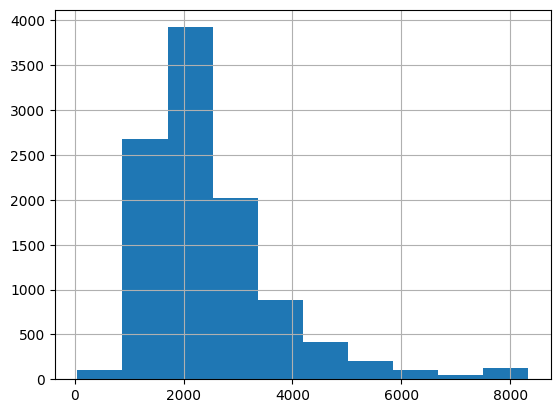

In [ ]:
df_major['MONTHLY_INCOME'].hist()

In [29]:
df_major['INCOME_LOG']

0        7.256768
1        7.458378
2        8.343078
3        7.569240
5        8.229778
           ...   
13714    8.430400
13715    7.196187
13716    7.450661
13717    8.517393
13719    7.601402
Name: INCOME_LOG, Length: 10499, dtype: float64

/Users/dumindu/venvs/interview-env/lib/python3.14/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


<Axes: >

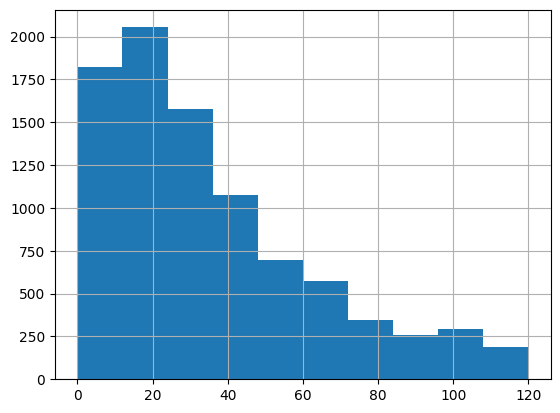

In [35]:
df_major['ACADMOS'].hist(bins=[0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, np.inf])

In [10]:
df[df['CARDHLDR'] == 1].groupby('DEFAULT').apply(lambda x: x['INCOME_PER_DEP'].mean())

DEFAULT
0    1640.739123
1    1537.914937
dtype: float64

<Axes: xlabel='INCOME_PER_DEP'>

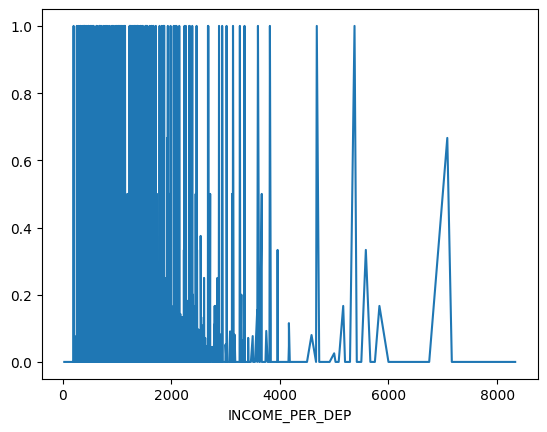

In [ ]:
# identifying noise in the feature space by looking at the distribution of the target variable across different values of the feature

In [21]:
df_major['MAJORDRG_lag1-12'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: [1 if val > 0 else 0 for val in x])
df_minor['MINORDRG_lag1-12'] = df_minor[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: [1 if val > 0 else 0 for val in x])

df_major['MAJORDRG_lag_all'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1)
df_minor['MINORDRG_lag_all'] = df_minor[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1)

#df['MAJORDRG_lag1-12'] = df[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: [1 if val > 0 else 0 for val in x])
#df['MINORDRG_lag1-12'] = df[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: [1 if val > 0 else 0 for val in x])

In [22]:
df_major['MAJORDRG_max_lag'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)
df_minor['MINORDRG_max_lag'] = df_minor[[f'MINORDRG_lag{i}' for i in range(1, 13)]].max(axis=1)

In [41]:
df_major.groupby('ADEPCNT').size()

ADEPCNT
0    5305
1    2055
2    1574
3    1052
4     380
5      95
6      29
7       7
9       2
dtype: int64

In [47]:
df_major['ADEPCNT_indicator>3'] = (df_major['ADEPCNT'] > 4).astype(int)

In [48]:
df_major.groupby('ADEPCNT_indicator>3')['DEFAULT'].mean()

ADEPCNT_indicator>3
0    0.095022
1    0.082707
Name: DEFAULT, dtype: float64

In [49]:
df_major.groupby('ACADMOS')['DEFAULT'].mean()

ACADMOS
0      0.300000
1      0.081967
2      0.128788
3      0.117904
4      0.053922
         ...   
446    0.000000
511    0.000000
528    0.000000
540    1.000000
564    0.000000
Name: DEFAULT, Length: 315, dtype: float64

In [1]:
df_major['INCOME_PER_DEP'] = df_major['MONTHLY_INCOME'] / (df_major['ADEPCNT'] + 1)

NameError: name 'df_major' is not defined

In [23]:
df_major.groupby('DEFAULT')['MAJORDRG_max_lag'].mean(), df_minor.groupby('DEFAULT')['MINORDRG_max_lag'].mean()

(DEFAULT
 0    0.273493
 1    0.302209
 Name: MAJORDRG_max_lag, dtype: float64,
 DEFAULT
 0    0.228980
 1    0.266064
 Name: MINORDRG_max_lag, dtype: float64)

In [128]:
df_major['APPLICATION_QUARTER'] = df_major['APPLICATION_DATE'].dt.quarter
df_major['APPLICATION_YEAR'] = df_major['APPLICATION_DATE'].dt.year
df_major['APPLICATION_MONTH'] = df_major['APPLICATION_DATE'].dt.month

In [5]:
df_major['APPLICATION_MONTH_SIN'] = np.sin(2 * np.pi * df_major['APPLICATION_DATE'].dt.month / 12)
df_major['APPLICATION_MONTH_COS'] = np.cos(2 * np.pi * df_major['APPLICATION_DATE'].dt.month / 12)

df_major['APPLICATION_QUARTER_SIN'] = np.sin(2 * np.pi * df_major['APPLICATION_DATE'].dt.quarter / 4)
df_major['APPLICATION_QUARTER_COS'] = np.cos(2 * np.pi * df_major['APPLICATION_DATE'].dt.quarter / 4)

In [6]:
df_major.groupby('DEFAULT')['APPLICATION_QUARTER_SIN'].mean()

DEFAULT
0   -0.009786
1   -0.016064
Name: APPLICATION_QUARTER_SIN, dtype: float64

In [7]:
df_major.groupby('DEFAULT')['APPLICATION_QUARTER_COS'].mean()

DEFAULT
0   -0.004630
1    0.004016
Name: APPLICATION_QUARTER_COS, dtype: float64

In [141]:
df_major[['APPLICATION_MONTH_SIN', 'APPLICATION_MONTH_COS']]

,APPLICATION_MONTH_SIN,APPLICATION_MONTH_COS
0,-1.000000e+00,-1.836970e-16
1,1.224647e-16,-1.000000e+00
2,5.000000e-01,-8.660254e-01
3,-8.660254e-01,5.000000e-01
5,-5.000000e-01,-8.660254e-01
...,...,...
13714,5.000000e-01,-8.660254e-01
13715,8.660254e-01,-5.000000e-01
13716,-8.660254e-01,5.000000e-01
13717,1.224647e-16,-1.000000e+00


In [142]:
df_major['DEFAULT'].value_counts()

DEFAULT
0    9503
1     996
Name: count, dtype: int64

In [144]:
mi = mutual_info_classif(df_major[['DEFAULT']], df_major['DEFAULT'])
print(mi)

[0.31374936]


In [120]:
df_major.groupby(['OWNRENT', 'ACADMOS'])['DEFAULT'].mean()

OWNRENT  ACADMOS
0        0          0.250000
         1          0.102041
         2          0.123810
         3          0.128049
         4          0.056962
                      ...   
1        432        0.000000
         446        0.000000
         511        0.000000
         528        0.000000
         540        1.000000
Name: DEFAULT, Length: 544, dtype: float64

In [127]:
df_major[df_major['OWNRENT']==1].groupby('DEFAULT').apply(lambda x: (x['ACADMOS']>60).mean())

DEFAULT
0    0.405675
1    0.399538
dtype: float64

In [117]:
df_major.groupby('APPLICATION_MONTH')['DEFAULT'].mean()

APPLICATION_MONTH
1     0.104551
2     0.075257
3     0.096372
4     0.104706
5     0.071823
6     0.110360
7     0.096597
8     0.087007
9     0.098018
10    0.077938
11    0.092150
12    0.123596
Name: DEFAULT, dtype: float64

In [90]:
df_major.groupby('APPLICATION_YEAR')['DEFAULT'].mean()

APPLICATION_YEAR
2021    0.092068
2022    0.092544
2023    0.099943
Name: DEFAULT, dtype: float64

In [21]:
(df_major['AGE']<20).sum()

np.int64(193)

In [109]:
((df_major['AGE'] > 65) & (df_major['AGE'] >75)).sum()

np.int64(24)

In [25]:
df_major.groupby('DEFAULT').apply(lambda x: (x['AGE']>50).mean())

DEFAULT
0    0.070399
1    0.067269
dtype: float64

In [26]:
df_major.groupby('DEFAULT').apply(lambda x: ((x['AGE'] > 25) & (x['AGE'] <= 50)).mean())

DEFAULT
0    0.717142
1    0.674699
dtype: float64

In [66]:
df_major.groupby('DEFAULT').apply(lambda x: (x['AGE']>40).mean())

DEFAULT
0    0.234558
1    0.219880
dtype: float64

In [73]:
(df_major['ACADMOS']<15).sum()

np.int64(2997)

In [75]:
df_major.groupby('DEFAULT').apply(lambda x: (x['ACADMOS']<18).mean())

DEFAULT
0    0.319373
1    0.315261
dtype: float64

In [57]:
df_major['ADEPCNT'].value_counts()

ADEPCNT
0    5305
1    2055
2    1574
3    1052
4     380
5      95
6      29
7       7
9       2
Name: count, dtype: int64

In [60]:
df_major.groupby('DEFAULT')['ADEPCNT'].apply(lambda x: (x>=3).mean())

DEFAULT
0    0.149742
1    0.142570
Name: ADEPCNT, dtype: float64

In [ ]:
# number of 0s before the first non-zero in each row of MAJORDRG_lag1-12
df_major['MAJORDRG_lag_latest_consecutive'] = df_major['MAJORDRG_lag1-12'].apply(lambda x: len(x) - max([i for i, val in enumerate(x) if val > 0]) - 1 if any(val > 0 for val in x) else 12)
df_major['MAJORDRG_lag_concentration'] = df_major['MAJORDRG_lag_all'].apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

In [ ]:
df_major['MAJORDRG_LAST_6'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 7)]].apply(lambda row: 

In [7]:
df_lag = pd.DataFrame(columns=[f'DRG_lag{i}' for i in range(1, 13)]+['CARDHLDR', 'DEFAULT'])
for i in range(1, 13):
    df_lag[f'DRG_lag{i}'] = df[f'MAJORDRG_lag{i}'] + df[f'MINORDRG_lag{i}']
df_lag['CARDHLDR'] = df['CARDHLDR']
df_lag['DEFAULT'] = df['DEFAULT']

In [9]:
df_lag['DRG_lag_concentration'] = df_lag[[f'DRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'DRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

In [11]:
df_lag[df_lag['CARDHLDR']==1].groupby('DEFAULT')['DRG_lag_concentration'].mean()

DEFAULT
0    0.447964
1    0.529635
Name: DRG_lag_concentration, dtype: float64

In [183]:
df_major['MAJORDRG_lag_ratio'] = df_major['MAJORDRG_lag_all'].apply(lambda x: sum(x) / (sum([1 for i in x if i == 0])) if any(x) else 0)

In [ ]:
df_major[['DEFAULT', 'MAJORDRG_lag_latest_consecutive', 'MAJORDRG_lag_concentration', 'MAJORDRG_consecutive_2', 'MAJORDRG_consecutive_3', 'MAJORDRG_max_lag', 'MAJORDRG_lag_ratio']].groupby('DEFAULT').mean()

,MAJORDRG_lag_latest_consecutive,MAJORDRG_lag_concentration,MAJORDRG_lag_concentration_1,MAJORDRG_consecutive_2,MAJORDRG_consecutive_3,MAJORDRG_max_lag,MAJORDRG_lag_ratio
DEFAULT,,,,,,,
0,10.069241,0.245028,0.049526,0.015995,0.008418,0.273493,0.039808
1,10.000000,0.282246,0.050870,0.011044,0.007028,0.302209,0.035691


In [170]:
df_minor['MINORDRG_lag_latest_consecutive'] = df_minor['MINORDRG_lag1-12'].apply(lambda x: len(x) - max([i for i, val in enumerate(x) if val > 0]) - 1 if any(val > 0 for val in x) else 12)
df_minor['MINORDRG_lag_concentration'] = df_minor['MINORDRG_lag1-12'].apply(lambda x: sum(x) / len([i for i in x if i > 0]) if any(i > 0 for i in x) else 0)

In [ ]:
df_minor[['DEFAULT', 'MINORDRG_lag_concentration', 'MINORDRG_lag_latest_consecutive', 'MINORDRG_consecutive_2', 'MINORDRG_consecutive_3', 'MINORDRG_max_lag', 'MINORDRG_lag_ratio']].groupby('DEFAULT').mean()

,MINORDRG_lag_concentration,MINORDRG_lag_latest_consecutive,MINORDRG_consecutive_2,MINORDRG_consecutive_3,MINORDRG_max_lag
DEFAULT,,,,,
0,0.165737,10.011154,0.008208,0.002315,0.228980
1,0.196787,9.638554,0.003012,0.000000,0.266064


In [76]:
df_lags = df[df['CARDHLDR'] == 1][['MAJORDRG_lag1', 'MAJORDRG_lag2',
       'MAJORDRG_lag3', 'MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6',
       'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10',
       'MAJORDRG_lag11', 'MAJORDRG_lag12','MINORDRG_lag1', 'MINORDRG_lag2',
       'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6',
       'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10',
       'MINORDRG_lag11', 'MINORDRG_lag12', 'DEFAULT']]

In [119]:
df_lags.groupby('DEFAULT').apply(lambda x: x.apply(lambda y: (y>2).sum()/len(x)))

,MAJORDRG_lag1,MAJORDRG_lag2,MAJORDRG_lag3,MAJORDRG_lag4,MAJORDRG_lag5,MAJORDRG_lag6,MAJORDRG_lag7,MAJORDRG_lag8,MAJORDRG_lag9,MAJORDRG_lag10,...,MINORDRG_lag3,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12
DEFAULT,,,,,,,,,,,,,,,,,,,,,
0,0.006209,0.000947,0.000105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011891
1,0.005020,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016064


In [122]:
df_lags.groupby('DEFAULT').apply(lambda x: x.sum())[['MAJORDRG_lag1', 'MAJORDRG_lag2',
       'MAJORDRG_lag3', 'MAJORDRG_lag4', 'MAJORDRG_lag5', 'MAJORDRG_lag6',
       'MAJORDRG_lag7', 'MAJORDRG_lag8', 'MAJORDRG_lag9', 'MAJORDRG_lag10',
       'MAJORDRG_lag11', 'MAJORDRG_lag12']]

,MAJORDRG_lag1,MAJORDRG_lag2,MAJORDRG_lag3,MAJORDRG_lag4,MAJORDRG_lag5,MAJORDRG_lag6,MAJORDRG_lag7,MAJORDRG_lag8,MAJORDRG_lag9,MAJORDRG_lag10,MAJORDRG_lag11,MAJORDRG_lag12
DEFAULT,,,,,,,,,,,,
0,574,199,91,44,19,11,5,1,1,1,0,2405
1,58,13,7,2,0,0,0,0,0,0,0,280


In [124]:
df_lags.groupby('DEFAULT').apply(lambda x: x.sum())[['MINORDRG_lag1', 'MINORDRG_lag2',
       'MINORDRG_lag3', 'MINORDRG_lag4', 'MINORDRG_lag5', 'MINORDRG_lag6',
       'MINORDRG_lag7', 'MINORDRG_lag8', 'MINORDRG_lag9', 'MINORDRG_lag10',
       'MINORDRG_lag11', 'MINORDRG_lag12' ]]

,MINORDRG_lag1,MINORDRG_lag2,MINORDRG_lag3,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12
DEFAULT,,,,,,,,,,,,
0,356,79,22,1,1,0,0,0,0,0,0,2088
1,30,3,0,0,0,0,0,0,0,0,0,258


array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

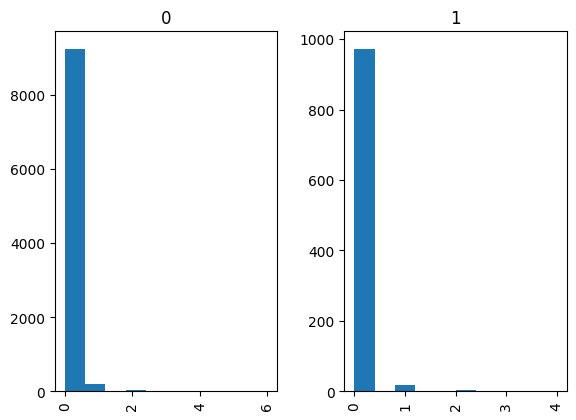

In [126]:
df_lags['MINORDRG_lag1'].hist(by=df_lags['DEFAULT'])

In [90]:
(y==1).sum()/len(y)

np.float64(0.0948661777312125)

<Axes: >

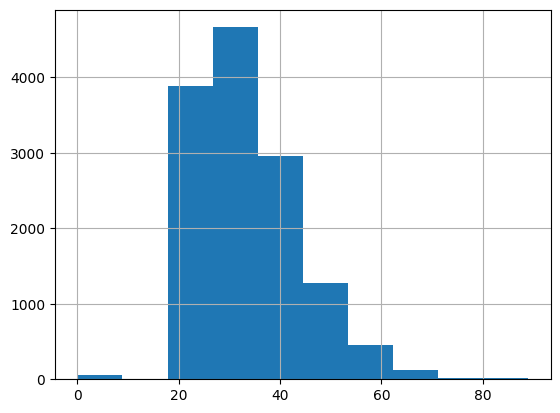

In [109]:
df['AGE'].round().hist()

In [95]:
X = df_lags.drop(columns=['DEFAULT'])
y = df_lags['DEFAULT']

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = XGBClassifier(scale_pos_weight=9)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]

print('Baseline precision:', (y==1).sum()/len(y))
print('PR AUC:', average_precision_score(y_test, y_pred_proba))

Baseline precision: 0.0948661777312125
PR AUC: 0.09608751101094172


In [44]:
df_major[df_major['DEFAULT']==1]

,MAJORDRG,MAJORDRG_lag1,MAJORDRG_lag2,MAJORDRG_lag3,MAJORDRG_lag4,MAJORDRG_lag5,MAJORDRG_lag6,MAJORDRG_lag7,MAJORDRG_lag8,MAJORDRG_lag9,MAJORDRG_lag10,MAJORDRG_lag11,MAJORDRG_lag12,MONTHLY_INCOME,ADEPCNT,ACADMOS,DEFAULT,MAJORDRG_lag1-12,MAJORDRG_lag_all
35,0,0,0,0,0,0,0,0,0,0,0,0,0,2433.333333,2,29,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
46,0,0,0,0,0,0,0,0,0,0,0,0,0,1800.000000,2,138,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
75,3,0,0,0,0,0,0,0,0,0,0,0,3,2166.666667,0,36,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3]"
104,4,0,0,0,0,0,0,0,0,0,0,0,4,2916.666667,2,175,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]"
109,3,0,0,0,0,0,0,0,0,0,0,0,3,3000.000000,3,30,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13665,0,0,0,0,0,0,0,0,0,0,0,0,0,1916.666667,2,11,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13669,0,0,0,0,0,0,0,0,0,0,0,0,0,2083.333333,4,72,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13682,0,0,0,0,0,0,0,0,0,0,0,0,0,1666.666667,2,24,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13696,0,0,0,0,0,0,0,0,0,0,0,0,0,2083.333333,0,62,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [58]:
df_new = pd.concat([df_major['MAJORDRG_lag_all'], df_minor[['MINORDRG_lag_all','DEFAULT']]], axis=1)

In [59]:
df_new

,MAJORDRG_lag_all,MINORDRG_lag_all,DEFAULT
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
5,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]",0
...,...,...,...
13714,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
13715,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
13716,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
13717,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0


In [60]:
df_new['lag_all'] = df_new.apply(lambda row: np.array(row['MAJORDRG_lag_all']) + np.array(row['MINORDRG_lag_all']), axis=1)

In [70]:
df_new[df_new['DEFAULT']==1]['lag_all'].values

array([array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
       array

In [45]:
df_minor[df_minor['DEFAULT']==1]

,MINORDRG,MINORDRG_lag1,MINORDRG_lag2,MINORDRG_lag3,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,MONTHLY_INCOME,ADEPCNT,ACADMOS,DEFAULT,MINORDRG_lag1-12,MINORDRG_lag_all
35,0,0,0,0,0,0,0,0,0,0,0,0,0,2433.333333,2,29,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
46,0,0,0,0,0,0,0,0,0,0,0,0,0,1800.000000,2,138,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
75,2,0,0,0,0,0,0,0,0,0,0,0,2,2166.666667,0,36,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]"
104,1,0,0,0,0,0,0,0,0,0,0,0,1,2916.666667,2,175,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
109,1,0,0,0,0,0,0,0,0,0,0,0,1,3000.000000,3,30,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13665,0,0,0,0,0,0,0,0,0,0,0,0,0,1916.666667,2,11,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13669,0,0,0,0,0,0,0,0,0,0,0,0,0,2083.333333,4,72,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13682,0,0,0,0,0,0,0,0,0,0,0,0,0,1666.666667,2,24,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
13696,0,0,0,0,0,0,0,0,0,0,0,0,0,2083.333333,0,62,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [37]:
df.groupby(['CARDHLDR', 'DEFAULT']).size()

CARDHLDR  DEFAULT
0         0          2945
1         0          9503
          1           996
dtype: int64

In [42]:
sum(df[df['CARDHLDR']==0]['MAJORDRG_lag1-12'].sum())

1410

In [22]:
df_major[df_major['DEFAULT']==1]['MAJORDRG_lag1-12'].apply(lambda x: sum(x)).value_counts(normalize=True)

MAJORDRG_lag1-12
0    0.833333
1    0.130522
2    0.025100
4    0.005020
3    0.004016
5    0.002008
Name: proportion, dtype: float64

In [24]:
import itertools
df_major['max_consecutive_majordrg_months'] = df_major['MAJORDRG_lag1-12'].apply(lambda x: max((sum(1 for _ in group) for value, group in itertools.groupby(x) if value == 1), default=0))

In [12]:
df_major[df_major['DEFAULT']==0]['MAJORDRG_lag1-12'].apply(lambda x: sum(x)).value_counts(normalize=True)

MAJORDRG_lag1-12
0     0.839103
1     0.090708
2     0.033253
3     0.012628
4     0.007050
5     0.005577
6     0.003473
7     0.002105
8     0.001894
11    0.001158
9     0.000737
10    0.000631
13    0.000526
14    0.000210
15    0.000210
21    0.000210
12    0.000210
16    0.000210
17    0.000105
Name: proportion, dtype: float64

In [121]:
df_major['last_major_lag'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: next((val for val in x if val > 0), 0))
df_major['last_major_lag_month'] = df_major[[f'MAJORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MAJORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: next((i+1 for i, val in enumerate(x, 1) if val > 0), 0))

In [122]:
df_minor['last_minor_lag'] = df_minor[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: next((val for val in x if val > 0), 0))
df_minor['last_minor_lag_month'] = df_minor[[f'MINORDRG_lag{i}' for i in range(1, 13)]].apply(lambda row: [row[f'MINORDRG_lag{i}'] for i in range(1, 13)], axis=1).apply(lambda x: next((i+1 for i, val in enumerate(x, 1) if val > 0), 0))

In [110]:
df_major['last_major_lag']

0        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
2        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
3        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
5        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
                         ...                 
13714    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
13715    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
13716    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
13717    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
13719    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Name: last_major_lag, Length: 10499, dtype: object

In [16]:
df_major['MAJORDRG_BURDEN'] = df_major['MAJORDRG']/df_major['MONTHLY_INCOME']
df_major['DEPENDENT_BURDEN'] = df_major['ADEPCNT']/df_major['MONTHLY_INCOME']
df_major['DEROGATORY_RATE'] = df_major['MAJORDRG']/(df_major['ACADMOS'] + 1)

In [37]:
df_major['FINANCIAL_SECURITY'] = (df_major['MONTHLY_INCOME'] * (df_major['ACADMOS']+1))/ (df_major['ADEPCNT']+1)
df_major['MAJORDRG_lag1_BURDEN'] = df_major['MAJORDRG_lag1']/df_major['FINANCIAL_SECURITY']
df_major['MAJORDRG_lag2_BURDEN'] = df_major['MAJORDRG_lag2']/df_major['FINANCIAL_SECURITY']
df_major['MAJORDRG_lag3_BURDEN'] = df_major['MAJORDRG_lag3']/df_major['FINANCIAL_SECURITY']

In [140]:
df_major.drop(['MAJORDRG_lag1-12'], axis=1).groupby('DEFAULT').mean()

TypeError: agg function failed [how->mean,dtype->object]

In [124]:
df_minor.groupby('DEFAULT').mean()

,MINORDRG,MINORDRG_lag1,MINORDRG_lag2,MINORDRG_lag3,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,MONTHLY_INCOME,ADEPCNT,ACADMOS,last_minor_lag,last_minor_lag_month
DEFAULT,,,,,,,,,,,,,,,,,,
0,0.268021,0.037462,0.008313,0.002315,0.000105,0.000105,0.0,0.0,0.0,0.0,0.0,0.0,0.219720,2550.138982,1.010418,55.941492,0.223193,1.853625
1,0.292169,0.030120,0.003012,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.259036,2381.970633,0.996988,54.431727,0.261044,2.304217


In [81]:
df_major[df_major['MAJORDRG_lag2']>0][['MAJORDRG_lag1', 'DEFAULT']].groupby('DEFAULT').mean()

,MAJORDRG_lag1
DEFAULT,
0,2.197368
1,2.090909


In [88]:
df_major['INDICATOR_MAJORDRG_lag2'] = df_major['MAJORDRG_lag2'].apply(lambda x: 1 if x>0 else 0)

In [39]:
df[df['CARDHLDR']==1].groupby('DEFAULT')[['MAJORDRG_lag1', 'MAJORDRG_lag2', 'MINORDRG_lag1', 'MINORDRG_lag2', 'MAJORDRG']].mean()

,MAJORDRG_lag1,MAJORDRG_lag2,MINORDRG_lag1,MINORDRG_lag2,MAJORDRG
DEFAULT,,,,,
0,0.060402,0.020941,0.037462,0.008313,0.352625
1,0.058233,0.013052,0.030120,0.003012,0.361446


In [99]:
df[df['CARDHLDR']==0].groupby('DEFAULT')['MAJORDRG'].value_counts(normalize=True)

DEFAULT  MAJORDRG
0        0           0.705942
         1           0.121902
         2           0.061800
         3           0.034975
         4           0.021732
         5           0.018336
         6           0.006791
         9           0.006791
         7           0.005093
         8           0.004414
         10          0.003396
         11          0.003396
         13          0.001698
         14          0.001019
         12          0.001019
         16          0.000340
         17          0.000340
         15          0.000340
         21          0.000340
         22          0.000340
Name: proportion, dtype: float64

In [98]:
df_major.groupby(['DEFAULT'])['MAJORDRG'].value_counts(normalize=True)

DEFAULT  MAJORDRG
0        0           0.839103
         1           0.090708
         2           0.033253
         3           0.012628
         4           0.007050
         5           0.005577
         6           0.003473
         7           0.002105
         8           0.001894
         11          0.001158
         9           0.000737
         10          0.000631
         13          0.000526
         21          0.000210
         15          0.000210
         14          0.000210
         12          0.000210
         16          0.000210
         17          0.000105
1        0           0.833333
         1           0.085341
         2           0.036145
         3           0.021084
         4           0.009036
         6           0.005020
         7           0.003012
         5           0.003012
         11          0.001004
         9           0.001004
         10          0.001004
         8           0.001004
Name: proportion, dtype: float64

In [30]:
(df_major['MAJORDRG_lag1']> 1).sum()

np.int64(133)

In [89]:
df_major.groupby('DEFAULT').mean()

,MAJORDRG_lag1,MAJORDRG_lag2,MAJORDRG_lag3,MAJORDRG_lag4,MAJORDRG_lag5,MAJORDRG_lag6,MAJORDRG_lag7,MAJORDRG_lag8,MAJORDRG_lag9,MAJORDRG_lag10,MAJORDRG_lag11,MAJORDRG_lag12,INDICATOR>10,LATE_MAJORDRG,INDICATOR_MAJORDRG_lag1,INDICATOR_MAJORDRG_lag2
DEFAULT,,,,,,,,,,,,,,,,
0,0.060402,0.020941,0.009576,0.004630,0.001999,0.001158,0.000526,0.000105,0.000105,0.000105,0.0,0.253078,0.004209,0.090919,0.035042,0.015995
1,0.058233,0.013052,0.007028,0.002008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.281124,0.008032,0.078313,0.036145,0.011044


In [21]:
df_minor.groupby('DEFAULT').mean()

,MINORDRG_lag1,MINORDRG_lag2,MINORDRG_lag3,MINORDRG_lag4,MINORDRG_lag5,MINORDRG_lag6,MINORDRG_lag7,MINORDRG_lag8,MINORDRG_lag9,MINORDRG_lag10,MINORDRG_lag11,MINORDRG_lag12,MINORDRG_last6,MINORDRG_first6
DEFAULT,,,,,,,,,,,,,,
0,0.037462,0.008313,0.002315,0.000105,0.000105,0.0,0.0,0.0,0.0,0.0,0.0,0.219720,0.048301,0.219720
1,0.030120,0.003012,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.259036,0.033133,0.259036


In [17]:
df[df['CARDHLDR'] == 1][['MAJORDRG', 'MINORDRG', 'DEFAULT']].groupby('DEFAULT').mean()

,MAJORDRG,MINORDRG
DEFAULT,,
0,0.352625,0.268021
1,0.361446,0.292169


<Axes: ylabel='Frequency'>

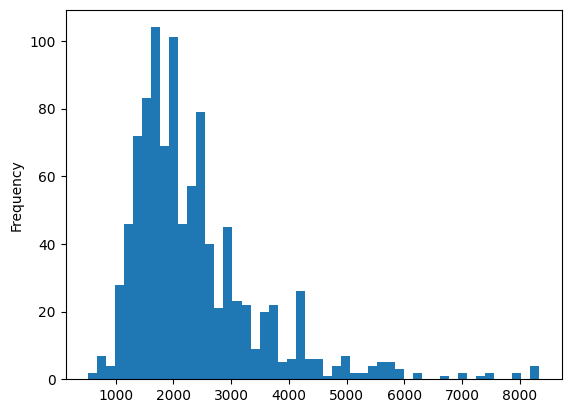

In [103]:
df[(df['CARDHLDR'] == 1) & (df['DEFAULT']==1)]['MONTHLY_INCOME'].plot.hist(bins=50)

<Axes: ylabel='Frequency'>

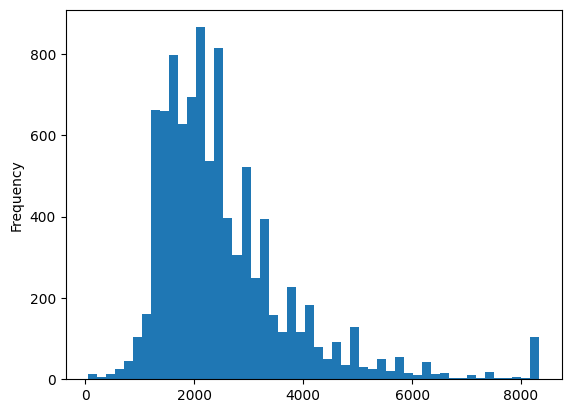

In [104]:
df[(df['CARDHLDR'] == 1) & (df['DEFAULT']==0)]['MONTHLY_INCOME'].plot.hist(bins=50)

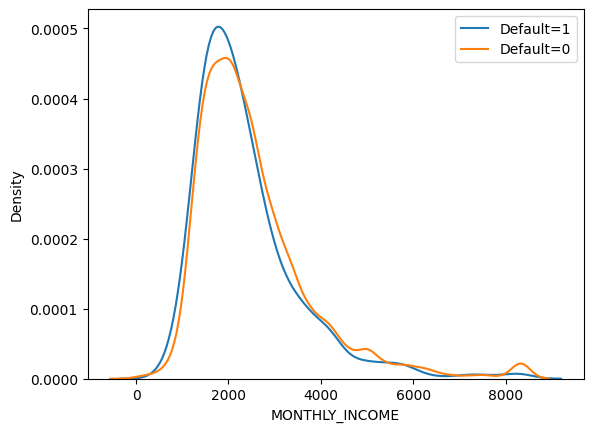

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(df[(df['CARDHLDR'] == 1) & (df['DEFAULT']==1)]['MONTHLY_INCOME'], label='Default=1')
sns.kdeplot(df[(df['CARDHLDR'] == 1) & (df['DEFAULT']==0)]['MONTHLY_INCOME'], label='Default=0')
plt.legend()
plt.show()